In [171]:
import numpy as np 
import pandas as pd 

# Data viz
import matplotlib.pyplot as plt
import seaborn as sns

# stats
import scipy.stats as stats

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# preporcessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [172]:
# read in the df
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

## Missing Values

In [173]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Notes**

Looks to be no missing values!

## Duplicates

In [174]:
# sum the duplicated rows
df.duplicated().sum()

np.int64(0)

**Notes**

Looks like there are no duplicated rows!

## Data Consistency

Within this section, I will verify the object features labels to ensure there are no:

1. Miss-spelled labels.
2. White Space.
3. Incorrect labelling.

In [175]:
# review the object columns and see what values we have and how many
ob_df = df.select_dtypes(include='object').copy()

n_unique = ob_df.nunique().sort_values()
unique_values = ob_df.apply(lambda x: x.unique())
sample_size = ob_df.count()

# return the result
pd.DataFrame(
    {
        "Unique Value Count":n_unique,
        "Unique Values":unique_values,
        "Data Sample Size":sample_size
    }
)

,Unique Value Count,Unique Values,Data Sample Size
Churn,2,"[No, Yes]",7043
Contract,3,"[Month-to-month, One year, Two year]",7043
Dependents,2,"[No, Yes]",7043
DeviceProtection,3,"[No, Yes, No internet service]",7043
InternetService,3,"[DSL, Fiber optic, No]",7043
MultipleLines,3,"[No phone service, No, Yes]",7043
OnlineBackup,3,"[Yes, No, No internet service]",7043
OnlineSecurity,3,"[No, Yes, No internet service]",7043
PaperlessBilling,2,"[Yes, No]",7043
Partner,2,"[Yes, No]",7043


**Notes**

* The data contains data on unique customers, as we have 7043 unique customer IDs which is equal to sample size.
* The total charges column contains almost a full set of unique data - 6531/7043. It is likely that we have customers paying the same amount. The next step for this feature is to convert into float value.
* The rest of the object features contain 2 - 4 unique values representing particular services the customer has/hasn't paid for.

In [176]:
# convert total charges to float value
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Notes**

Looks like we have NaN values! Lets see what they are and impute

In [177]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**Notes**

The sample extracted paints a picture of brand new customers due to their tenure being zero and there are no recorded NaN for the remaining features.

Based on this information I will impute the NaN data with the monthly charge where I have assumed they have paid their first monthly payment. Moreover, I will add a feature "New Customer" where it will identify these customers in the modelling phase.

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


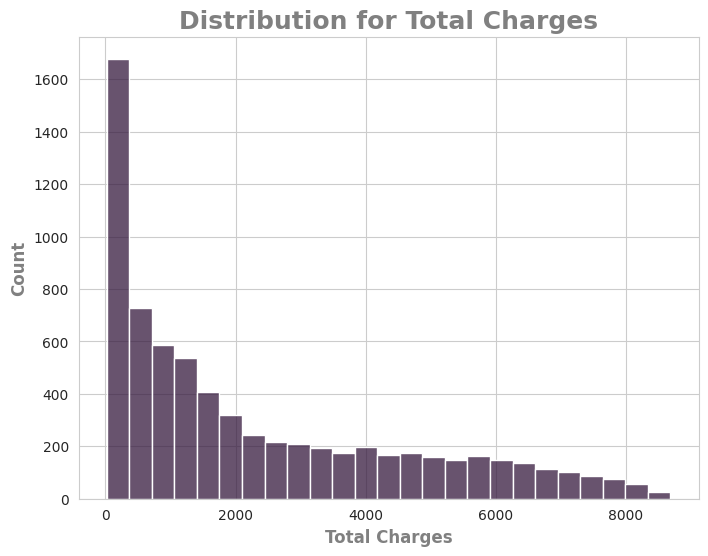

In [178]:
# what does the distribution look like?

plt.figure(figsize=(8,6))

#------------------
# Create visual
#------------------
sns.histplot(data=df,x='TotalCharges');

#------------------
# print statistics
#------------------

print(df['TotalCharges'].describe())

#------------------
# Adjust visual
#------------------
plt.title(
    "Distribution for Total Charges",
    fontsize=18,
    fontweight='bold',
    color='grey'
);

plt.xlabel(
    "Total Charges",
    fontsize=12,
    fontweight='bold',
    color='grey'
);

plt.ylabel(
    "Count",
    fontsize=12,
    fontweight='bold',
    color='grey'
);

**Notes**

Based on the distribution and descriptive statistics, we are safe imputing with the monthly charge.

In [179]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Outliers

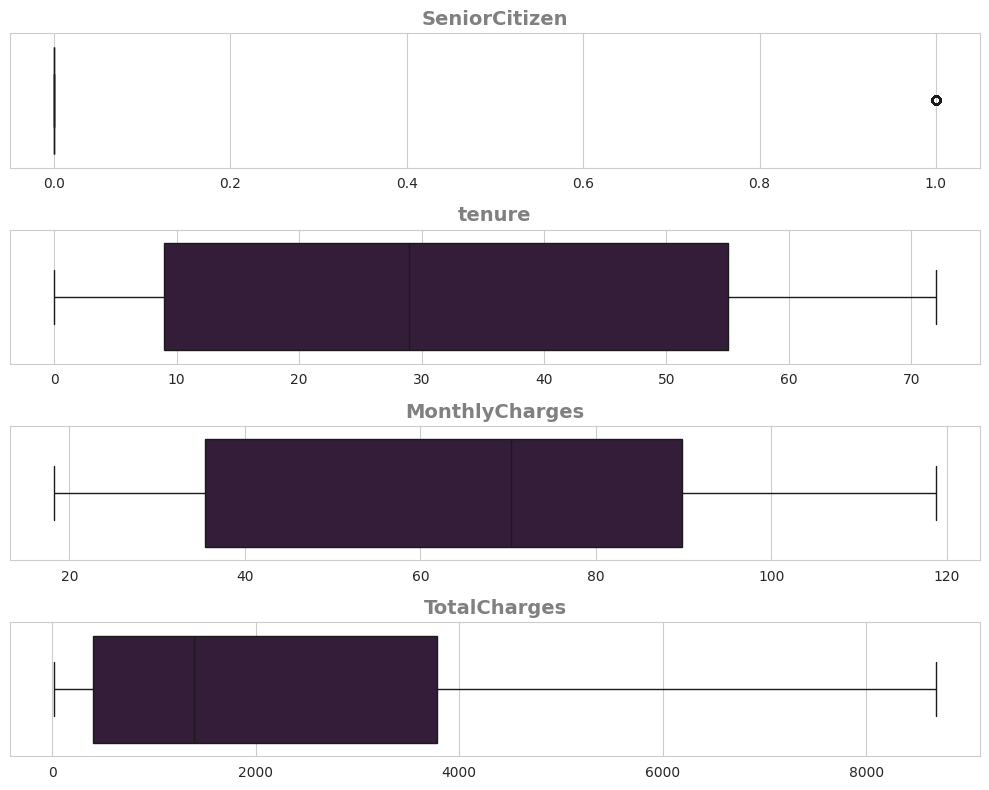

In [180]:
# lets visulaise using box plots to quickly show outliers and go from there

num_df = df.select_dtypes(exclude='object').copy()

fig, axes = plt.subplots(4,1,figsize=(10,8))

counter = 0


for i in num_df.columns:
    sns.boxplot(data=num_df,x=i,ax=axes[counter])

    #------------
    # add title
    #------------
    axes[counter].set_title(
        f"{i}",
        fontsize=14,
        fontweight='bold',
        color='grey')
    axes[counter].set_xlabel("")

    # increase counter
    counter+=1

plt.tight_layout()

**Notes**

**Outlier Viewpoint**
1. There are no evident outliers in the dataset according to the boxplots.
2. The Senior Citizen feature contains 1 and 0.

**Statistics Viewpoint**
1. The range of the data for total charges and tenure is relatively large from inspection. However, we do not have a comparison/baseline, so this customer churn rate could be severe.

2. Monthly charges are vastly different, meaning each customer pays extra for a given service add-on.

3. The tenure distribution indicates that 50% of these customers have a tenure between ~9 months and ~55 months, while the median sits at ~29 months.

4. The Total Charges feature distribution shows 50% of revenue lies between ~£800 and ~£3800.

**Exploratory Questions**
1. Of the customers who churned, what was their average revenue, monthly charges, and tenure?
By answering this, I will be able to see how much Telco made from these customers before they churned and how long it took them to do so. From a commercial perspective, you want to understand how much these customers were paying and for how long. Perhaps they were paying too much and the company lost out to a competitor on price?

2. What services were they paying for?
This question leads me to investigate the likely causes of churn in terms of services. Did these customers churn because of a particular service? Hopefully, the answers will lead to recommended actions for Telco to focus on to improve their offerings. Machine Learning is great, but you could have an "all-singing, all-dancing" model that can predict any customer to churn; if your offerings are below market standards, you will continue to lose customers.

3. Are there upselling opportunities?
This question will guide me in identifying services that customers pay for and have not churned. Perhaps the customers who paid for Tech Support increased their chance of not churning because of having a human expert to go to in times of need. Therefore, identifying a service that tackles Telco's problem with a two-pronged approach: improve churn rate and increase revenue through upselling.



# EDA

Questions to explore:

1. Of the customers who churned, what was their average revenue, monthly charges, and tenure?
2. What services were they paying for?
3. Are there upselling opportunities? (What are the non-churned customers paying for that churned did not?)

These are my baseline questions to explore and expand upon, but there is no doubt that I will add more as we go on.

## What is the percentage split of churn?

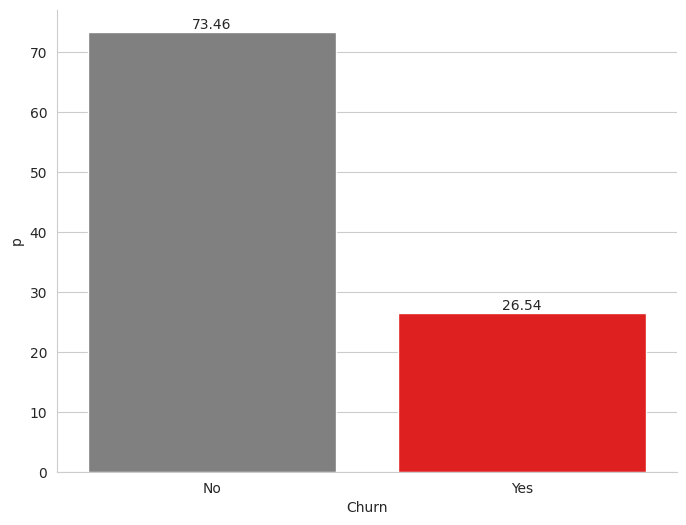

In [181]:
# set the style
sns.set_style("whitegrid")


custom_colors = {
    'Yes':'red',
    'No':'grey'
}

# create new df containing the split
churn_count = (
    df.groupby('Churn')
    .agg({'customerID':'count'})
    .reset_index()
)

# rename columns
churn_count.rename(columns={'customerID':'Count of Churn'},inplace=True)

# sample size
all_cust = df['customerID'].count()

# calculate p
churn_count['p'] = round((churn_count['Count of Churn']/all_cust)*100,2)


#------------------------
#   viz the results
#------------------------

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=churn_count,
    x='Churn',
    y='p',
    hue='Churn',
    palette=custom_colors,
    legend=False
);

# show labels
for container in ax.containers:
    ax.bar_label(container)

sns.despine()

**Notes**

It is clear that we have unbalanced data, so I will need to ensure that my train and test split are stratified. This ensures I have equal proportion sizes in the samples, instead of randomly sampling the data where we face the risk of train with most of the churn customers and test with very little. Therefore, this strategy reduces the risk of overfitting in the modelling phase.

## Of the customers who churned, what was their average revenue, monthly charges, and tenure?

In [182]:
# split the data with stratification
x = df.drop(columns='Churn').copy()
y = df['Churn']

# capture data type
original_types = df.dtypes.to_dict()

# split the data. We will create x_train, x_test later
train_df, test_df = train_test_split(df, test_size=0.3, stratify=df['Churn'], random_state=42)

# Re-apply dtypes
train_df = train_df.astype(original_types)
test_df = test_df.astype(original_types)

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 5557 to 5639
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        4930 non-null   object 
 1   gender            4930 non-null   object 
 2   SeniorCitizen     4930 non-null   int64  
 3   Partner           4930 non-null   object 
 4   Dependents        4930 non-null   object 
 5   tenure            4930 non-null   int64  
 6   PhoneService      4930 non-null   object 
 7   MultipleLines     4930 non-null   object 
 8   InternetService   4930 non-null   object 
 9   OnlineSecurity    4930 non-null   object 
 10  OnlineBackup      4930 non-null   object 
 11  DeviceProtection  4930 non-null   object 
 12  TechSupport       4930 non-null   object 
 13  StreamingTV       4930 non-null   object 
 14  StreamingMovies   4930 non-null   object 
 15  Contract          4930 non-null   object 
 16  PaperlessBilling  4930 non-null   object 
 1

In [183]:
# what is the sample variability for churn proportion?

# As this is just a sample of customers wihtin Telco - they're likely to take on new customers
# This is important because:
# 1. if Telco take of another 100 customers and operations stay the same, we can approximate how many of those customers are likely to churn.
# 2. We must calculate the Standard Error to determine if our 26.54% is a precise estimate 
# or if it’s likely to fluctuate significantly in a different sample due to random sampling noise.

churn_proportion = (
    train_df
    .groupby('Churn')
    .agg({'customerID':'count'})
    .reset_index()
)

# rename columns
churn_proportion.rename(columns={'customerID':'Count of Churn'},inplace=True)

# calculate p
churn_proportion['p'] = round((churn_count['Count of Churn']/all_cust)*100,2)

sample_p = churn_proportion.loc[churn_proportion['Churn']=='Yes','p'].item()/100
sample_n = len(train_df)
sample_variation = np.sqrt((sample_p*(1-sample_p))/sample_n)

# show results
SE = round(sample_variation*100,2)
print(f"The SE: {SE}%")
print(f"Success/Failure Condition {sample_n*sample_p:.0f}")
print(f"Success/Failure Condition {sample_n*(1-sample_p):.0f}")

# due to CLT we can assume the proportion is from an approximately normal distribution as we have a large n sample size.
# we also know that each sample is independent as the churn of one customer does not influence the outcome of another.
# finally our success failre condition for both proportions >= 10.
# Therefore, we are safe to use confience intervals. 


print(f"The 95% Confidence Interval MOE: +/- {1.96*SE:.2f}%") 
print(f"The Upper 95% Confidence Interval: {sample_p*100 + 1.96*SE:.2f}%") 
print(f"The Lower 95% Confidence Interval: {sample_p*100 - 1.96*SE:.2f}%") 
print(f"The sampled proportion: {sample_p*100:.2f}%")

The SE: 0.63%
Success/Failure Condition 1308
Success/Failure Condition 3622
The 95% Confidence Interval MOE: +/- 1.23%
The Upper 95% Confidence Interval: 27.77%
The Lower 95% Confidence Interval: 25.31%
The sampled proportion: 26.54%


**Notes**

Our sample proportion has a very small Standard Error which means:

1. Our sample proportion will be close to the population proportion, as Standard Error measures the level of spread for the sampled proporion distribution - it is the equivalent of the standard deviation for a given distribution.
2. Our proportion is reliable, as there will be little variation in the proportion value due to the small SE value. Using the Empirical Rule, we can say that 68% of the sampled proportions lie within 1 SE (+/- 0.63%), 95% of the sampled proportions lie within 2 SE (+/- 1.26%) & 99.7% of the sampled proportions are within 3 SE (+/- 1.89%).
3. By using the SE, we can calculate the confience interval at 95% and can conclude that the population proportion for Telco customers are between 25.31% and 27.77%. In other words, if I select the same sample size 100 times, I would expect 95 of those intervals to contain the true population proportion.
4. The small Standard Error indicates that our estimate is highly precise and unlikely to be the result of a high-variance, unrepresentative sample.

For Telco, this means that if their operations stay as they are and they take on 100 new customers today, they can expect to see between 25-28 customers churn over time.

Note - the above does not consider the characteristics of each customer and just the overall proportion, as we have yet to dig into the data.

  Churn   count        mean          std    min       25%       50%  \
0    No  3622.0  2563.89844  2351.982728  18.90  562.7875  1673.600   
1   Yes  1308.0  1576.22370  1943.484725  18.85  138.7500   705.075   

         75%      max  
0  4264.9000  8672.45  
1  2376.9375  8684.80  


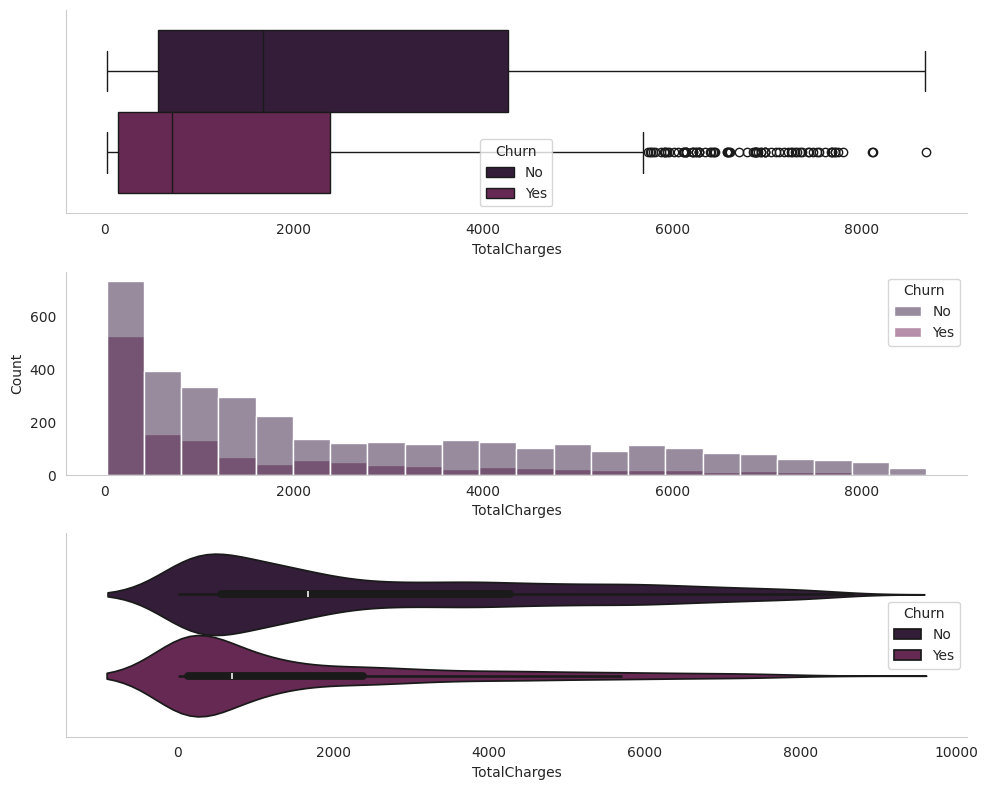

In [184]:
# set palette
sns.set_palette(sns.color_palette('rocket'))

# review customer churn revenue
churn_rev = (
    train_df.groupby('Churn')['TotalCharges']
    .describe()
    .reset_index()
)


print(churn_rev)

# show distributions
fig, axes = plt.subplots(3,1,figsize=(10,8))

sns.boxplot(
    data=train_df,
    x='TotalCharges',
    hue='Churn',
    ax=axes[0]
);

sns.histplot(
    data=train_df,
    x='TotalCharges',
    hue='Churn',
    ax=axes[1]
);

sns.violinplot(
    data=train_df,
    x='TotalCharges',
    hue='Churn',
    ax=axes[2]
)


# adjust visuals
plt.tight_layout()
sns.despine()

for i in range(3):
    axes[i].grid(False)

**Notes**

The distributions of the revenue made by the sampled customers suggest that Telco did not make a substantial amount of revenue from the churned customers suggesting:

1. They churn quickly meaning tenure within telco is low for this sampled customer base.
2. They are paying small monthly fees, which suggests price might not be a factor of churning.

Lets review the relationship between tenure and total charges to understand the relationship of the two groups.

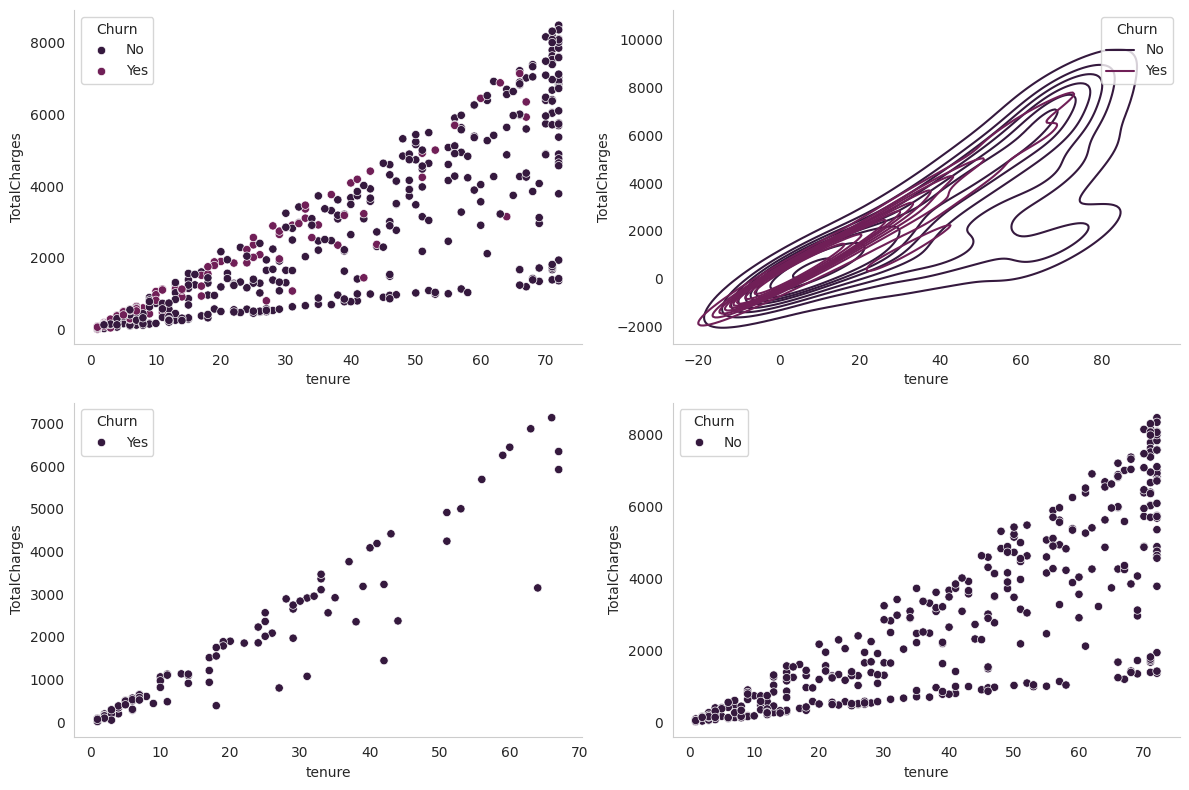

In [185]:
# visualise th relationships between total charges and tenure

# take random sample
random_sample = train_df.sample(500,random_state=42).copy()

fig, axes = plt.subplots(2,2,figsize=(12,8))

sns.scatterplot(
    data=random_sample,
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[0,0]
)

sns.kdeplot(
    data=random_sample,
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[0,1]
)

# isolate the groups
sns.scatterplot(
    data=random_sample.loc[random_sample['Churn']=='Yes'],
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[1,0]
)

sns.scatterplot(
    data=random_sample.loc[random_sample['Churn']=='No'],
    x='tenure',#independent variable
    y='TotalCharges', # dependent variable
    hue='Churn',
    ax=axes[1,1]
)

# adjust the plots
for i in range(2):
    for j in range(2):
        axes[i,j].grid(False)


plt.tight_layout()
sns.despine()

**Notes**

The random sample of 500 customers shows:

1. Customers that haven't churned show signs of different customer grouping due to the shape of the relationship expanding as the tenure increases - strong evidence of heteroscedasticity.
2. There is overlap with the two customer groups with their total charges, suggesting similar packages. This will require further analysis and customer grouping.
3. The relationship with tenure and total charges for churned customers is linear, but shows some outlier customers as the tenure increases, potentially signaling another customer group.
4. The linear relationship shows a potential customer segment that is at high risk of churning. However, this is speculative at this moment in time as further analysis is required. However, given the relationship at the upper banding of total charges, it does provide evidence for further exploration.

Lets dig deeper into monthly charges and see what the data says.

  Churn   count      mean        std    min    25%    50%      75%     max
0    No  3622.0  61.32032  31.265296  18.40  25.10  64.45  88.5375  118.75
1   Yes  1308.0  75.00130  24.569710  18.85  56.25  80.00  94.4625  118.35


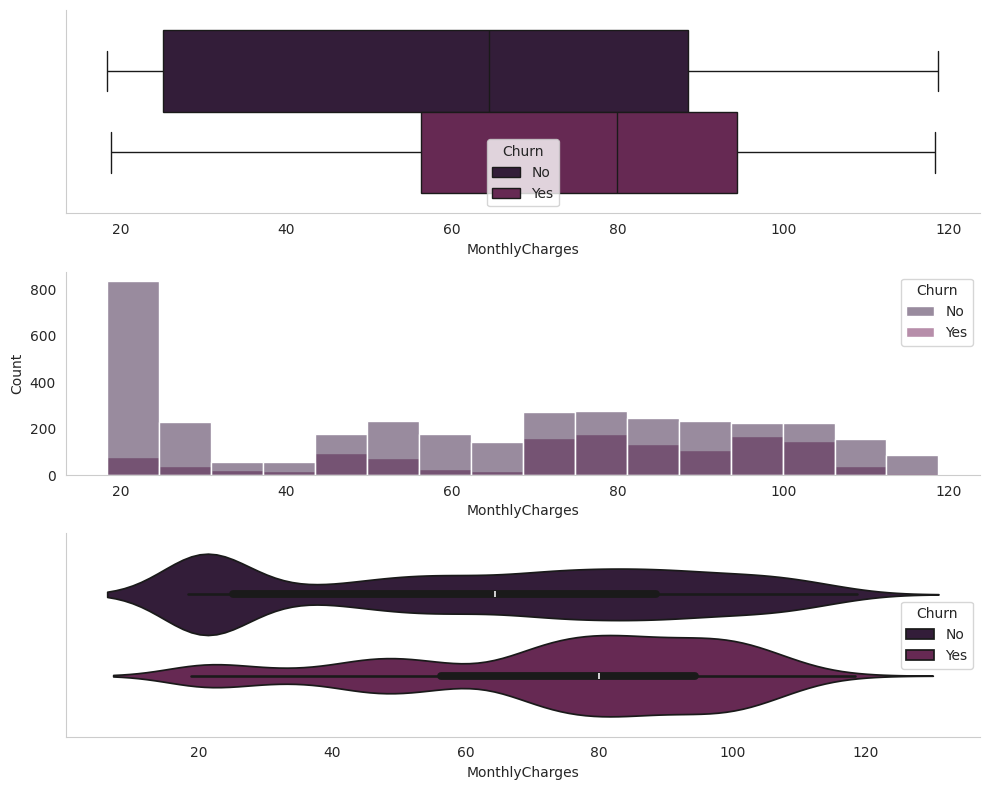

In [186]:
# review customer churn revenue
churn_rev = (
    train_df.groupby('Churn')['MonthlyCharges']
    .describe()
    .reset_index()
)


print(churn_rev)

# show distributions
fig, axes = plt.subplots(3,1,figsize=(10,8))

sns.boxplot(
    data=train_df,
    x='MonthlyCharges',
    hue='Churn',
    ax=axes[0]
);

sns.histplot(
    data=train_df,
    x='MonthlyCharges',
    hue='Churn',
    ax=axes[1]
);

sns.violinplot(
    data=train_df,
    x='MonthlyCharges',
    hue='Churn',
    ax=axes[2]
)


# adjust visuals
plt.tight_layout()
sns.despine()

for i in range(3):
    axes[i].grid(False)

**Notes**

A considerable difference in distributioins, where we can see that the churned customers typically paid more per month than the active customers. Given we have two sample size, let's conduct a hypothesis test to validate our findings.

In [187]:
# Hypothesis test assumpions - t test (both z and t test results converge after a large sample size)

#1. the data is sampled from a normal distribution
#2. the sample is independent

# step 1 - test the sample for normality
churn_sample = train_df[train_df['Churn']=='Yes'].copy()
no_churn_sample = train_df[train_df['Churn']=='No'].copy()

# compare mean to median. when mean = median, there is evidence to suggest the sample is normally distributed
def mean_v_median(sample_a,feature):

    # calculate the sample mean
    sample_a_mean = round(sample_a[feature].mean(),2)
    sample_a_median = round(sample_a[feature].median(),2)

    diff = sample_a_mean - sample_a_median

    if np.abs(diff)==0:
        return print(f"Difference = {diff:.2f} , Mean = Median")
    else:
        return print(f"Difference = {diff:.2f} , Mean <> Median")


mean_v_median(churn_sample,feature='MonthlyCharges')
mean_v_median(no_churn_sample,feature='MonthlyCharges')

def test_normality(sample,feature,test_feature):
    # use Shapiro-Wilk Test where alpha=0.05
    churn_stat, p_val = stats.shapiro(sample[feature])
    print("-" * 100)
    # show results
    if p_val < 0.05:
        print("Conclusion: Data is NOT normally distributed (Reject H0)")
    else:
        print("Conclusion: Data appears normally distributed (Fail to reject H0)")
    print("-" * 100)


# h0: The sample data is normally distributed
# h1: The sample data is not normally distributed

test_normality(churn_sample,feature='MonthlyCharges',test_feature='Churn = Yes')
test_normality(no_churn_sample,feature='MonthlyCharges',test_feature='Churn = No')

Difference = -5.00 , Mean <> Median
Difference = -3.13 , Mean <> Median
----------------------------------------------------------------------------------------------------
Conclusion: Data is NOT normally distributed (Reject H0)
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Conclusion: Data is NOT normally distributed (Reject H0)
----------------------------------------------------------------------------------------------------


**Notes**

Our data is not Normally distributed, but this is not a problem due to the Central Limit Theorem (CLT). According to MatLab, "Both the z-test and the t-test are relatively robust with respect to departures from this assumption [Sampling from a Normal Distribution], so long as the sample size n is large enough."

Because both tests compute a sample mean, the CLT states that the mean sample distribution is approximately normal where the mean of that sample is equal to the population. In other words, when you take samples of n=50 customers k times and compute the mean, the distribution of those mean values will be approximately normal and equal to the population parameter.

This means that we are able to conduct a t-test on our two samples without violating the assumptions!

Source - https://uk.mathworks.com/help/stats/hypothesis-test-assumptions.html

In [188]:
# set up the hypothesis test

# h0: Churned Customer Monthly Billing = Active Customer Monthly Billing
# h1: Churned Customer Monthly Billing <> Active Customer Monthly Billing

alpha = 0.05

# samples
churned = churn_sample['MonthlyCharges']
active = no_churn_sample['MonthlyCharges']


# set up the t-test
t_stat, p_val = stats.ttest_ind(churned,active, equal_var=False) #we do not know if variances are equal

# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
	# calculate the size of samples
	n1, n2 = len(d1), len(d2)
	# calculate the variance of the samples
	s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
	# calculate the pooled standard deviation
	s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
	# calculate the means of the samples
	u1, u2 = np.mean(d1), np.mean(d2)
	# calculate the effect size
	return (u1 - u2) / s

# calculate ecohendffect size
e_size = cohend(churned,active)

# calc the results
print("-" * 100)
if p_val <= alpha:    
    print("There is strong evidence to reject the Null Hypothesis")
    print(f"p = {p_val:.2f}")
    # what is the effect size?
    print(f"Effect size {e_size:.2f}")
else:
    print("There is no evidence to reject the Null Hypothesis")
    print(f"p={p_val:.2f}")
    # what is the effect size?
    print(f"Effect size {e_size:.2f}")
print("-" * 100)

----------------------------------------------------------------------------------------------------
There is strong evidence to reject the Null Hypothesis
p = 0.00
Effect size 0.46
----------------------------------------------------------------------------------------------------


**Notes**

The above test shows that the two group's population mean monthly payment are statistically different with a medium effect size. This means that the population mean for Churned customers is 0.46 standard deviations away from the population mean for active customers.

These results indicate that monthly billing aids in the churn rate for customers, but it is not the prime suspect due to the effect size results. Moreover, the monthly billing are driven by the services that the customers pay for which means I need to identify the services these customers are paying for to identify the churn drivers.

This means that to answer the question on "is pricing a factor in customer churn?" - partly, but one can't be certain due to the medium effect size, which suggests a service problem these customers are paying for.

## What services were they (Churn Customers) paying for?

In [189]:
# lets determine the most expensive customers - what are they paying for?

mask = (train_df['MonthlyCharges']>=94.46)&(train_df['Churn']=='Yes')

high_monthly_costs = (
    train_df.loc[mask]
           .select_dtypes(include='object')
            .drop(columns=['customerID','gender','Partner','Dependents'])
           .copy()
)

# count the obj variables and see if there is a pattern

total_customers = high_monthly_costs['PhoneService'].count()

#---------------
# Data Agg
#---------------

# create a blank list to use for union
all_summaries = []

for i in high_monthly_costs.columns:
    if i != 'Churn':
        temp = (
            high_monthly_costs.groupby(i)['Churn']
                            .count()
                            .reset_index()
        )

        # rename the cols
        temp.columns = ['Feature','Count']

        # add feature name to show what is what
        temp['Feature_Name']=i

        # add percentage
        temp['Percentage_of_Sample'] = round(temp['Count']/total_customers*100,2)

        # append to list
        all_summaries.append(temp)
        
        
# Union everything together at once
final_df = pd.concat(all_summaries, ignore_index=True)

# show the top % of the sample
final_df.sort_values(by='Percentage_of_Sample',ascending=False).head(10)      

,Feature,Count,Feature_Name,Percentage_of_Sample
0,Yes,327,PhoneService,100.00
3,Fiber optic,327,InternetService,100.00
13,Yes,315,StreamingTV,96.33
15,Yes,314,StreamingMovies,96.02
20,Yes,288,PaperlessBilling,88.07
2,Yes,266,MultipleLines,81.35
16,Month-to-month,249,Contract,76.15
4,No,248,OnlineSecurity,75.84
10,No,225,TechSupport,68.81
9,Yes,205,DeviceProtection,62.69


In [190]:
# recreate the above into a function

def service_analysis(df_,mask):
    #---------------
    # Data Agg
    #---------------
    high_monthly_costs = (
        df_.loc[mask]
           .select_dtypes(include='object')
           .drop(columns=['customerID','gender','Partner','Dependents'])
           .copy()
    )
    
    # count the obj variables and see if there is a pattern
    
    total_customers = high_monthly_costs['PhoneService'].count()
    

    
    # create a blank list to use for union
    all_summaries = []
    
    for i in high_monthly_costs.columns:
        if i != 'Churn':
            temp = (
                high_monthly_costs.groupby(i)['Churn']
                                .count()
                                .reset_index()
            )
    
            # rename the cols
            temp.columns = ['Feature','Count']
    
            # add feature name to show what is what
            temp['Feature_Name']=i
    
            # add percentage
            temp['Percentage_of_Sample'] = round(temp['Count']/total_customers*100,2)
    
            # append to list
            all_summaries.append(temp)
            
            
    # Union everything together at once
    final_df = pd.concat(all_summaries, ignore_index=True).sort_values(by='Percentage_of_Sample',ascending=False)

    return final_df

In [191]:
# create the mask for the bottom 25%
mask = (train_df['MonthlyCharges']<56.25)&(train_df['Churn']=='Yes')

# show data
service_df = service_analysis(train_df,mask)

service_df

,Feature,Count,Feature_Name,Percentage_of_Sample
25,Month-to-month,296,Contract,90.80
5,DSL,252,InternetService,77.30
16,No,217,TechSupport,66.56
1,Yes,212,PhoneService,65.03
7,No,210,OnlineSecurity,64.42
13,No,203,DeviceProtection,62.27
19,No,201,StreamingTV,61.66
10,No,201,OnlineBackup,61.66
22,No,200,StreamingMovies,61.35
2,No,186,MultipleLines,57.06


**Notes**

It looks like Fiber Optic & Phone Service are the serives driving prices up and potentially a reason for customer churn due to the significantly high proportions - 100%!. This is because both services only appear in the top 25% quartile of churned customers monthly spend.

The analysis also highlights the services that are potentially problematic for Telco, meaning they could be the reason for customer churn.

In [192]:
# does phone service and fiber optic appear in the top 25% of active customers?
q = np.quantile(train_df['MonthlyCharges'].loc[train_df['Churn']=='No'],0.75)

mask = (train_df['MonthlyCharges']>=q)&(train_df['Churn']=='No')

# show data
service_df = service_analysis(train_df,mask)

service_df.head(10)

,Feature,Count,Feature_Name,Percentage_of_Sample
0,Yes,906,PhoneService,100.00
4,Fiber optic,850,InternetService,93.82
16,Yes,753,StreamingMovies,83.11
14,Yes,752,StreamingTV,83.00
2,Yes,706,MultipleLines,77.92
21,Yes,664,PaperlessBilling,73.29
10,Yes,629,DeviceProtection,69.43
8,Yes,615,OnlineBackup,67.88
5,No,478,OnlineSecurity,52.76
12,Yes,468,TechSupport,51.66


In [193]:
# does phone service and fiber optic appear in the bottom 25% of active customers?
q = np.quantile(train_df['MonthlyCharges'].loc[train_df['Churn']=='No'],0.25)

mask = (train_df['MonthlyCharges']<=q)&(train_df['Churn']=='No')

# show data
service_df = service_analysis(train_df,mask)

service_df.head(10)

,Feature,Count,Feature_Name,Percentage_of_Sample
1,Yes,886,PhoneService,97.58
10,No internet service,886,OnlineBackup,97.58
8,No internet service,886,OnlineSecurity,97.58
6,No,886,InternetService,97.58
16,No internet service,886,StreamingTV,97.58
18,No internet service,886,StreamingMovies,97.58
14,No internet service,886,TechSupport,97.58
12,No internet service,886,DeviceProtection,97.58
2,No,758,MultipleLines,83.48
22,No,652,PaperlessBilling,71.81


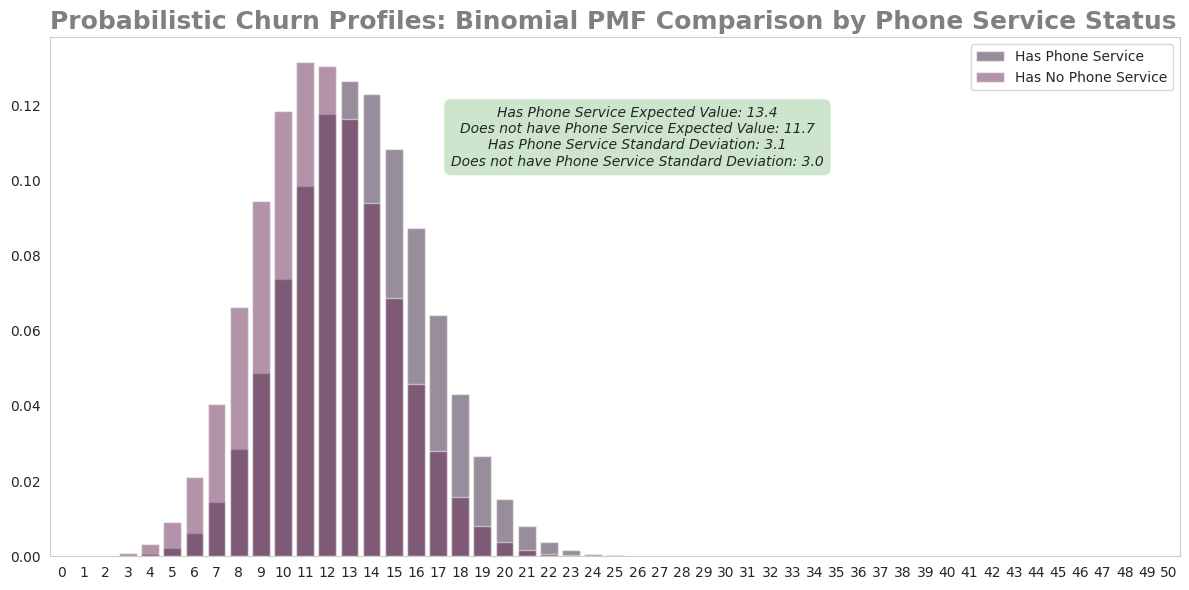

In [194]:
# lets focus on phone service customers and internet service customers.
# Model the probabilities of churn using the Binomial distribution

# assumptions to meet
# 1. The trials/customers are independent - One customer churning does not influence another
# 2. There are two outcomes - failure/success - Yes: Churn and Not Churned
# 3. There are a fixed number of trials - Yes, we are working with a random sample in train_df
# 4. The probability (p) of success is the same in each trial (customer) - 
# This is assumed when comparing groups: internet service and phone service groups





sample_a = (
    train_df
    .loc[train_df['PhoneService']=='Yes']
    .copy()
)

sample_b = (
    train_df
    .loc[train_df['PhoneService']=='No']
    .copy()
)

# get sample sizes
sample_a_n = len(sample_a)
sample_b_n = len(sample_b)

#calculate the sample p for churn
sample_a_agg = (
    sample_a.groupby('Churn')['PhoneService']
          .count()
          .reset_index()
)

sample_b_agg = (
    sample_b.groupby('Churn')['PhoneService']
          .count()
          .reset_index()
)

# calc the %
sample_a_agg['p'] = sample_a_agg['PhoneService']/sample_a_n
sample_b_agg['p'] = sample_b_agg['PhoneService']/sample_b_n

sample_a_p = sample_a_agg.loc[sample_a_agg['Churn']=='Yes', 'p'].item()
sample_b_p = sample_b_agg.loc[sample_b_agg['Churn']=='Yes', 'p'].item()

# fit a binomial distribution
n_trials = 50
x = np.arange(0,n_trials+1)

# we want the probability mass function
sample_a_binom_dist = stats.binom.pmf(x,n_trials,sample_a_p)
sample_b_binom_dist = stats.binom.pmf(x,n_trials,sample_b_p)

# we use n_trials as this is the number of independent trials we wish to run the model.
# We do not wish to use the sample size as these are different size!

# calculate the mean and stdev of the distribution
sample_a_mean = n_trials*sample_a_p
sample_b_mean = n_trials*sample_b_p

#stdv
sample_a_std = np.sqrt(n_trials * sample_a_p * (1 - sample_a_p))
sample_b_std = np.sqrt(n_trials * sample_b_p * (1 - sample_b_p))

# show the results
plt.figure(figsize=(12,6))

# show results in barplot
sns.barplot(
    x=x,
    y=sample_a_binom_dist,
    label='Has Phone Service',
    alpha=0.5
)

sns.barplot(
    x=x,
    y=sample_b_binom_dist,
    label='Has No Phone Service',
    alpha=0.5
)

# add the stat in a text box

txt = (
    f"Has Phone Service Expected Value: {sample_a_mean:.1f}\n"
    f"Does not have Phone Service Expected Value: {sample_b_mean:.1f}\n"
    f"Has Phone Service Standard Deviation: {sample_a_std:.1f}\n"
    f"Does not have Phone Service Standard Deviation: {sample_b_std:.1f}"
)

plt.text(
    x=26,
    y=max(sample_b_binom_dist)-0.02,
    s=txt,
    fontstyle='italic',
    ha='center',
    va='center',
    bbox=dict(
        facecolor='green',
        alpha=0.2,
        boxstyle="round,pad=0.5"
    )
)

# add title
plt.title(
    "Probabilistic Churn Profiles: Binomial PMF Comparison by Phone Service Status",
    fontsize=18,
    fontweight='bold',
    color='grey',
    loc='left'
    
)

# adjust visual
plt.tight_layout()
plt.grid(False)

**Notes**

By using the Binomial Distribution, we have evidence to suggest that the customers who pay for phone services are not driving high levels of customer churn. This suggests that this service is slightly to blame for churn rate due to the differences in the distribution locations, but, I would argue, the evidence shows very little influence.

From a business perspective, this could be good news in that their phone service is not be causing the churning issue. However, further analysis is required to Statistically determine this argument.

In [195]:
# Lets use the approximate normal distribution to determine the probability
# of 10  to 16 customers churning in these groups.

# Why have we got a Approximate Normal distribution from the Binomial?
# Both distributions are symetrical with one peak due to either large n value or a p value close to 0.5.
# based on my knowledge of the sample churn proportion, I would suggest it is closer to 0, thus I have a large enough sample size.

# I need to verify that p*n >= 10 and n*(1-p)>=10

print(f"Phone Service & Churned - n*p: {sample_a_p*sample_a_n}")
print(f"No Phone Service & Churned - n*p: {sample_b_p*sample_b_n}")

print(f"Phone Service & Did Not Churn - n*(1-p): {sample_a_n*(1-sample_a_p)}")
print(f"No Phone Service & Did Not Churn - n*(1-p): {sample_b_n*(1-sample_b_p)}")

Phone Service & Churned - n*p: 1192.0
No Phone Service & Churned - n*p: 116.0
Phone Service & Did Not Churn - n*(1-p): 3242.0
No Phone Service & Did Not Churn - n*(1-p): 380.0


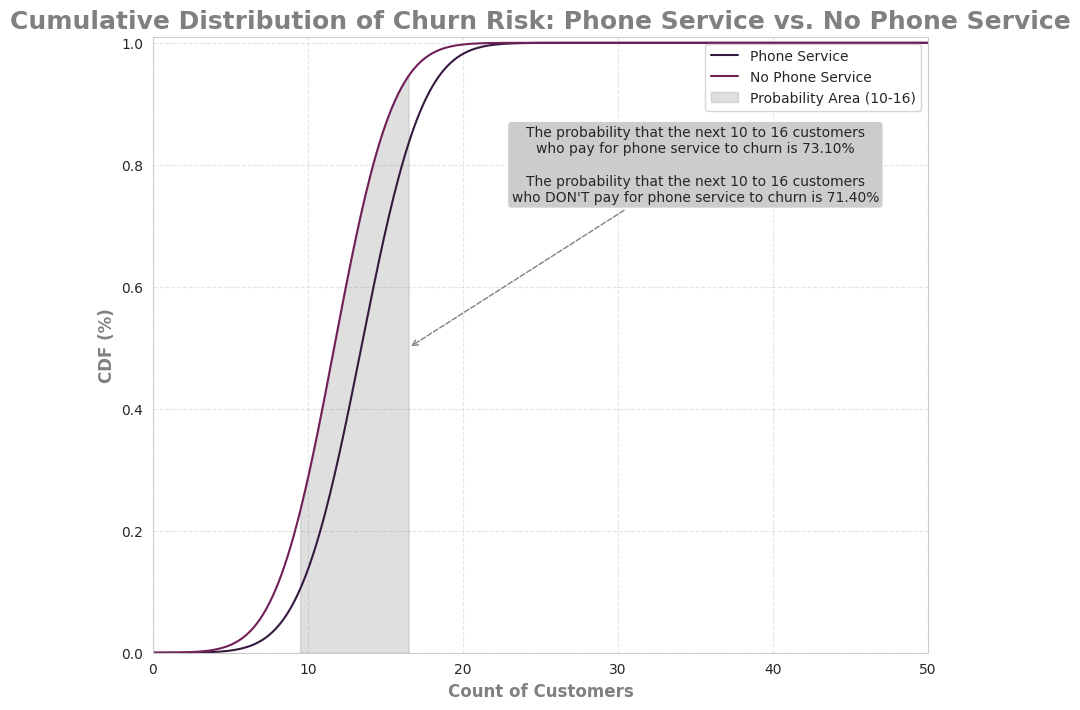

In [196]:
# lets convert to an approximately normal distribution
n = 50

# calculate the mean and stdev of the distribution
sample_a_mean = n*sample_a_p
sample_b_mean = n*sample_b_p

#stdv
sample_a_std = np.sqrt(n * sample_a_p * (1 - sample_a_p))
sample_b_std = np.sqrt(n * sample_b_p * (1 - sample_b_p))

# show results
# we are using the stats.norm.cdf function to standardise our data and extract our probabilities.
# this is the same process as manually standardising the data, then looking up the zscore in the z table!

phone_service_prob = stats.norm.cdf(16.5,sample_a_mean,sample_a_std) - stats.norm.cdf(9.5,sample_a_mean,sample_a_std)
no_phone_service_prob = stats.norm.cdf(16.5,sample_b_mean,sample_b_std) - stats.norm.cdf(9.5,sample_b_mean,sample_b_std)


# visulise in cdf chart
cdf_x = np.linspace(0,n,500)
cdf_a = stats.norm.cdf(cdf_x,sample_a_mean,sample_a_std)
cdf_b = stats.norm.cdf(cdf_x,sample_b_mean,sample_b_std)

plt.figure(figsize=(10,8))

# plot the results

plt.plot(
    cdf_x,
    cdf_a,
    label="Phone Service"
);


plt.plot(
    cdf_x,
    cdf_b,
    label="No Phone Service"
);

# create a fill of where the probability lies
x_fill = np.linspace(9.5, 16.5, 500)
cdf_fill = stats.norm.cdf(x_fill, sample_b_mean, sample_b_std)

plt.fill_between(
    x=x_fill,
    y1=cdf_fill,
    y2=0,
    color = 'grey',
    alpha = 0.25,
    label = 'Probability Area (10-16)'
)

# add title
plt.title(
    "Cumulative Distribution of Churn Risk: Phone Service vs. No Phone Service",
    fontsize=18,
    fontweight='bold',
    color='grey'
)

plt.xlabel(
    "Count of Customers",
    fontsize=12,
    fontweight='bold',
    color='grey'
)

plt.ylabel(
    "CDF (%)",
    fontsize=12,
    fontweight='bold',
    color='grey'
)

# annotate the visual
txt = (
    f"The probability that the next 10 to 16 customers\nwho pay for phone service to churn is {phone_service_prob*100:.2f}%\n\n"
    f"The probability that the next 10 to 16 customers\nwho DON'T pay for phone service to churn is {no_phone_service_prob*100:.2f}%"
)

bbox = dict(
    boxstyle="round", 
    fc="0.8"
)

arrowprops = dict(
    arrowstyle="->",
    color='grey',
    linestyle='--'
    
)


plt.annotate(
    text=txt,
    xy=(16.5, 0.5),
    xytext=(35,0.8),
    arrowprops=arrowprops,
    bbox=bbox,
    ha='center',
    va='center'
)

# drop grid visibility
plt.grid(
    True, 
    linestyle='--', 
    alpha=0.5
)

# set the xmin and ymin to 0
plt.xlim(
    left=0,
    right=50
)
plt.ylim(
    bottom=0,
    top=1.01
)

# add legend
plt.legend();

**Notes**

When analysing the high end (top 25% quartile) of monthly bills for churned customers, we saw that all the customers were paying for phone service. However, we have found no evidence of this service being the driver of churn due to overlapping Binomial Distributions, which means that there are little differences in probabilities in n customers churning whether they pay for this service or not.

The results from the Binomial distribution and CDF make sense as Phone service was also seen in the same quartile for active customers! For Telco, this provides evidence of confidence in their phone service and perhaps an upselling opportunity to new customers to reduce the probability of new customer churn.

In [197]:
# create a function for the above to analyse other groups
def binomial_dist(df,feature, serive_option_a, serive_option_b, serive_option_c=None):
    
    # get the samples for service
    sample_a = (
    df
    .loc[train_df[feature]==serive_option_a]
    .copy()
    )
    
    sample_b = (
        df
        .loc[train_df[feature]==serive_option_b]
        .copy()
    )

    # get sample sizes
    sample_a_n = len(sample_a)
    sample_b_n = len(sample_b)
    
    #calculate the sample p for churn
    sample_a_agg = (
        sample_a.groupby('Churn')[feature]
              .count()
              .reset_index()
    )
    
    sample_b_agg = (
        sample_b.groupby('Churn')[feature]
              .count()
              .reset_index()
    )
    
    # calc the %
    sample_a_agg['p'] = sample_a_agg[feature]/sample_a_n
    sample_b_agg['p'] = sample_b_agg[feature]/sample_b_n
    
    sample_a_p = sample_a_agg.loc[sample_a_agg['Churn']=='Yes', 'p'].item()
    sample_b_p = sample_b_agg.loc[sample_b_agg['Churn']=='Yes', 'p'].item()
    
    # fit a binomial distribution
    n_trials = 100
    x = np.arange(0,60)
    
    # we want the probability mass function
    sample_a_binom_dist = stats.binom.pmf(x,n_trials,sample_a_p)
    sample_b_binom_dist = stats.binom.pmf(x,n_trials,sample_b_p)
        
    
    # calculate the mean and stdev of the distribution
    sample_a_mean = n_trials*sample_a_p
    sample_b_mean = n_trials*sample_b_p
    
    #stdv
    sample_a_std = np.sqrt(n_trials * sample_a_p * (1 - sample_a_p))
    sample_b_std = np.sqrt(n_trials * sample_b_p * (1 - sample_b_p))
    
    # show the results
    plt.figure(figsize=(12,6))

        # control flow for third option
    if serive_option_c:
        sample_c = (
        train_df
        .loc[train_df[feature]==serive_option_c]
        .copy()
    )
        #Sample size
        sample_c_n = len(sample_c)

        # calculate p
        sample_c_agg = (
            sample_c.groupby('Churn')[feature]
                  .count()
                  .reset_index()
        )
        
        # calc the %
        sample_c_agg['p'] = sample_c_agg[feature]/sample_c_n
        sample_c_p = sample_c_agg.loc[sample_c_agg['Churn']=='Yes', 'p'].item()

        # fit the binomial
        sample_c_binom_dist = stats.binom.pmf(x,n_trials,sample_c_p)

        # calculate the mean and stdev of the distribution
        sample_c_mean = n_trials*sample_c_p
        sample_c_std = np.sqrt(n_trials * sample_c_p * (1 - sample_c_p))

        # show results in barplot
        sns.barplot(
            x=x,
            y=sample_c_binom_dist,
            label=f'{serive_option_c}',
            alpha=0.5
        )
    
    # show results in barplot
    sns.barplot(
        x=x,
        y=sample_a_binom_dist,
        label=f'{serive_option_a}',
        alpha=0.5
    )
    
    sns.barplot(
        x=x,
        y=sample_b_binom_dist,
        label=f'{serive_option_b}',
        alpha=0.5
    )

    
    # add title
    plt.title(
        f"Probabilistic Churn Profiles: Binomial PMF Comparison by {feature} Status",
        fontsize=18,
        fontweight='bold',
        color='grey',
        loc='left'
        
    )
    
    # adjust visual
    plt.tight_layout()
    plt.grid(False)

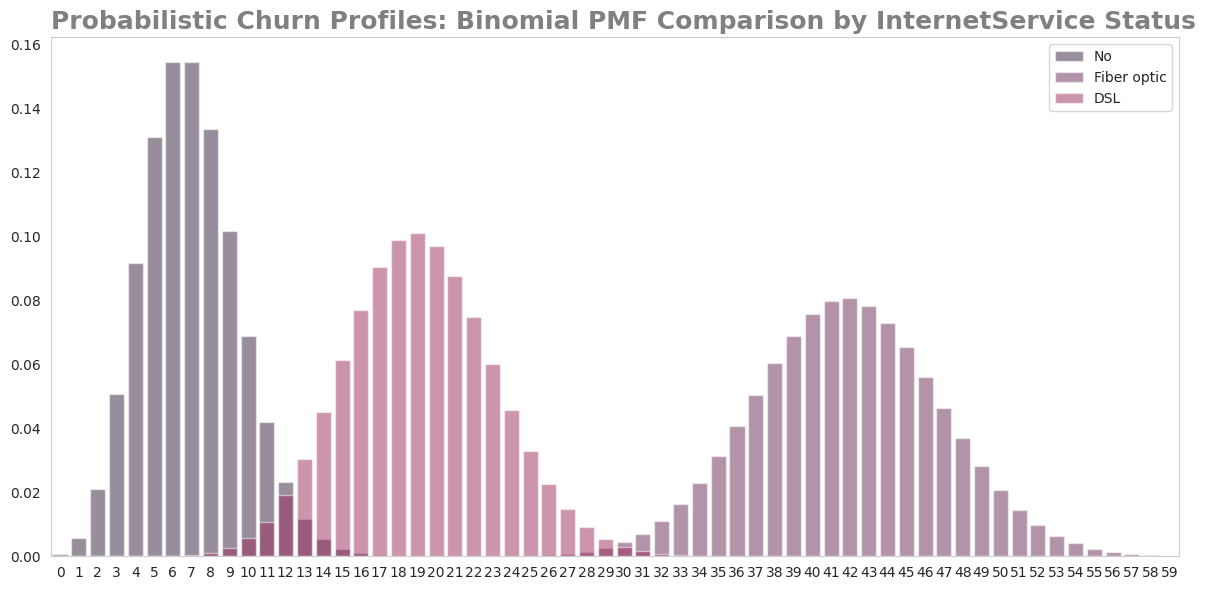

In [198]:
binomial_dist(train_df,'InternetService','Fiber optic','DSL','No')

**Notes**

Now we are starting to see where the problem lies. Fiber Optic has clear separation from the the other two distributions, which means it experiences higher levels of churn relative to the other two distributions.

From a probabilistic point of view there appears to be a 8% chance that 42 customers will churn for every 100 customers within this customer group whereas there other will be 0 or close to.

By using the Binomial Distribution, I have been able to visualise and compare the probability of k customers churning which also identifies key signals for the ML phase of this project. I would not be surprised if this service was a key feature in predicting customer churn!

The key question is, of those Fiber Optic customers what add-ons were they paying for? Is there a service that keeps customers active?

In [199]:
fiber_optic_customers = train_df[train_df['InternetService']=='Fiber optic'].copy()

all_cust_count = len(train_df)
fo_n = len(fiber_optic_customers)

print(f"The proportion of Fiber Optic Customers: {fo_n/all_cust_count*100:.2f}%")

The proportion of Fiber Optic Customers: 44.16%


**Notes**

Looks like Fiber Optic makes up a large proportion of Telco's customerbase. This would explain why their Binomial Distribution sits so high in the above Histogram, but evidence suggests that this service is Telco's problem.

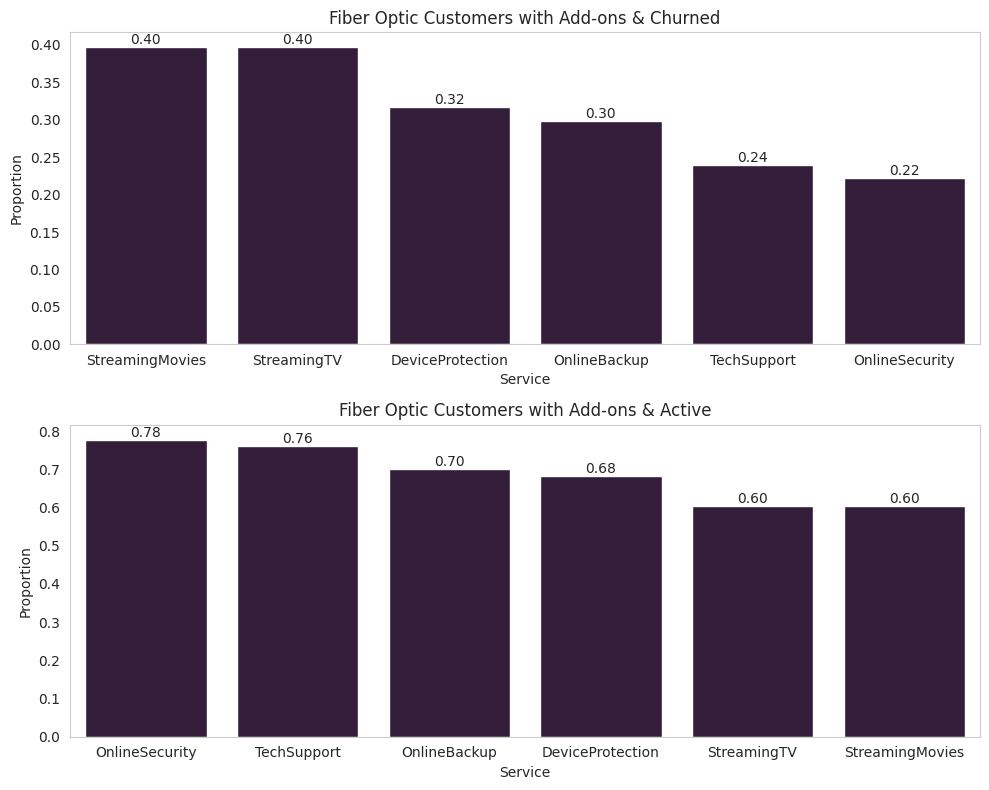

In [200]:
# what are the services in internet causing problems?
# Here we are looking at each service individually and not in conbinations.
# As inn, customers might has 2 or more added services.

internet_addon = ['OnlineSecurity',
                  'OnlineBackup',
                  'DeviceProtection',
                  'TechSupport',
                  'StreamingTV',
                  'StreamingMovies']

all_data = []
for service in internet_addon:
    temp = (
        fiber_optic_customers
        .groupby(service)['Churn']
        .value_counts(normalize=True)
        .reset_index()
    )
    # rename columns
    temp.columns=['Has Service','Churn','Proportion']
    
    # add feature name into df
    temp['Service'] = service

    #append data
    all_data.append(temp)


# show data in df
fo_services = pd.concat(all_data, ignore_index=True)

# filter the data
has_services = (fo_services['Has Service']=='Yes')&(fo_services['Churn']=='Yes')
has_no_services = (fo_services['Has Service']=='Yes')&(fo_services['Churn']=='No')

# agg the data
has_serv = (
    fo_services
    .loc[has_services]
    .sort_values(by='Proportion',ascending=False)
)

has_no_serv = (
    fo_services
    .loc[has_no_services]
    .sort_values(by='Proportion',ascending=False)
)

fig,axes = plt.subplots(2,1,figsize=(10,8))


#visualise the results
sns.barplot(
    data=has_serv,
    x='Service',
    y='Proportion',
    ax=axes[0]
);

sns.barplot(
    data=has_no_serv,
    x='Service',
    y='Proportion',
    ax=axes[1]
);

# set titles for clarity
axes[0].set_title(
    "Fiber Optic Customers with Add-ons & Churned"
)

axes[1].set_title(
    "Fiber Optic Customers with Add-ons & Active"
)




plt.tight_layout()


for i in range(2):
    axes[i].grid(False)
    # show the data labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

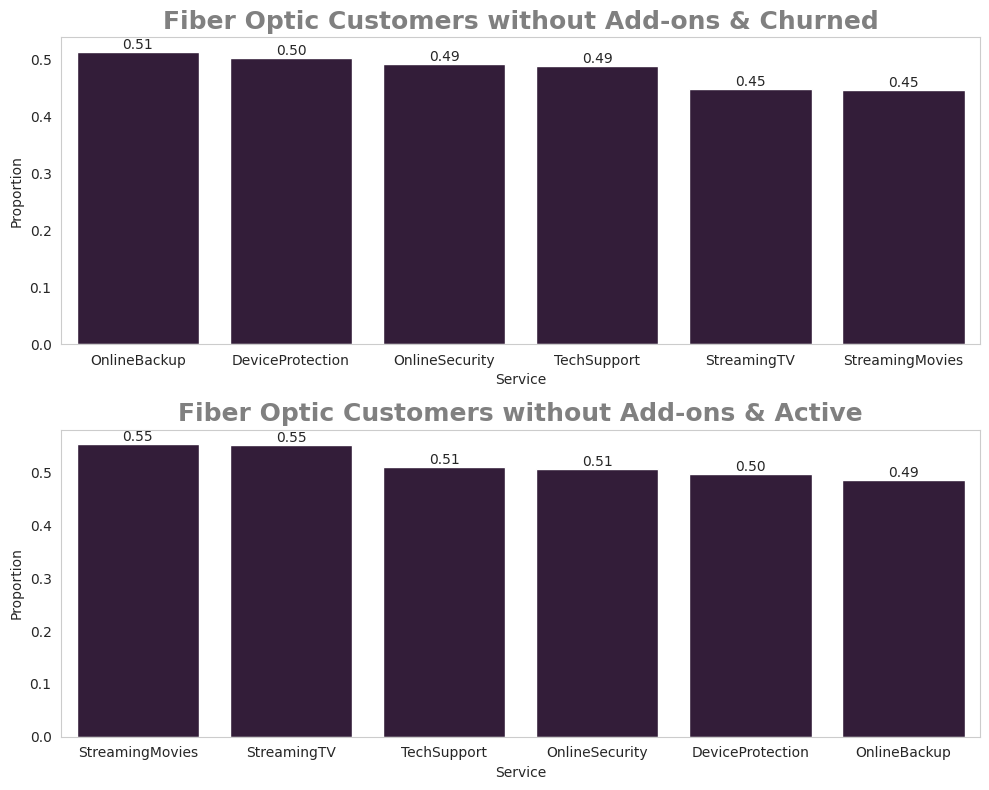

In [201]:
# filter the data
has_services = (fo_services['Has Service']=='No')&(fo_services['Churn']=='Yes')
has_no_services = (fo_services['Has Service']=='No')&(fo_services['Churn']=='No')

# agg the data
has_serv = (
    fo_services
    .loc[has_services]
    .sort_values(by='Proportion',ascending=False)
)

has_no_serv = (
    fo_services
    .loc[has_no_services]
    .sort_values(by='Proportion',ascending=False)
)

fig,axes = plt.subplots(2,1,figsize=(10,8))


#visualise the results
sns.barplot(
    data=has_serv,
    x='Service',
    y='Proportion',
    ax=axes[0]
);

sns.barplot(
    data=has_no_serv,
    x='Service',
    y='Proportion',
    ax=axes[1]
);

# set titles for clarity
axes[0].set_title(
    "Fiber Optic Customers without Add-ons & Churned",
    fontsize=18,
    fontweight='bold',
    color='grey'
)

axes[1].set_title(
    "Fiber Optic Customers without Add-ons & Active",
    fontsize=18,
    fontweight='bold',
    color='grey'
)




plt.tight_layout()


for i in range(2):
    axes[i].grid(False)
    # show the data labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

**Notes**

It looks like additional services to Fiber Optic reduce the chance of customer churn. Based on the above, it apears that when customers sign up for Online Security or Tech Support, there is a 24% chance or 22% chance of that customer churning.

This is very interesting! What this suggests is that these add-ons to Internet Services reduce the chance of customer churn. However, the Statistician in me is demanding for a Hypothesis test to vlaidate that this sample did not happen by chance.

In [202]:
# h0: Fiber Optic Churned Customers with Online Security proportion = Fiber Optic Active Customers with Online Security proportion
# h1: Fiber Optic Churned Customers with Online Security proportion <> Fiber Optic Active Customers with Online Security proportion

# The above is essentially asking, did our sample happen by chance?
# if we are unable to reject h0, then there is evidence to suggest chance has influenced the sample parameter.
# if we are able to reject h0, then there is evidence to suggest that chance is not at play and
# we can evidence that these add-ons are reducing customer churn!


# filter the data

n_with_security = len(fiber_optic_customers[fiber_optic_customers['OnlineSecurity'] == 'Yes'])
n_no_security = len(fiber_optic_customers[fiber_optic_customers['OnlineSecurity'] == 'No'])

x_with_security = len(fiber_optic_customers[(fiber_optic_customers['OnlineSecurity'] == 'Yes') & (fiber_optic_customers['Churn'] == 'Yes')])
x_no_security = len(fiber_optic_customers[(fiber_optic_customers['OnlineSecurity'] == 'No') & (fiber_optic_customers['Churn'] == 'Yes')])

# input proportions from above viz
sample_a_p = 0.22
sample_b_p = 0.49

# Calculate Pooled Proportion
P_p = (x_with_security + x_no_security) / (n_with_security + n_no_security)

# calculate the diff
p_diff = sample_a_p - sample_b_p

se = P_p*(1-P_p)*(1/n_with_security + 1/n_no_security)

denom = np.sqrt(se)

test_stat = p_diff / denom


print(f"The observed Z-score: {test_stat:.2f}")

# get p-value : the probability that our observations were observed by chance
p_value = 2*stats.norm.sf(abs(test_stat)) # two-tailed test

print(f"P-Value: {p_value:.2f}")

#alpha = 0.05
if p_value< 0.05:
    print("Reject the Null Hypothesis: The difference is statistically significant.")
else:
    print("Fail to reject the Null Hypothesis: The difference could be due to chance.")

The observed Z-score: -11.40
P-Value: 0.00
Reject the Null Hypothesis: The difference is statistically significant.


In [203]:
# How much does this service reduce churn?

# use confidnece intervals to establish this
z_critical = 1.96

# input proportions from above viz
sample_a_p = 0.22
sample_b_p = 0.49

n_with_security = len(fiber_optic_customers[fiber_optic_customers['OnlineSecurity'] == 'Yes'])
n_no_security = len(fiber_optic_customers[fiber_optic_customers['OnlineSecurity'] == 'No'])


# calculate the diff
p_diff = sample_a_p - sample_b_p

se_a = sample_a_p*(1-sample_a_p)/n_with_security
se_b = sample_b_p*(1-sample_b_p)/n_no_security

moe = z_critical*np.sqrt(se_a+se_b)

# calculate the intrval
ci_lower = (sample_b_p - sample_a_p) - moe
ci_upper = (sample_b_p - sample_a_p) + moe

print(f"Online Security reduces churn by {ci_lower:.2%} to {ci_upper:.2%}")

Online Security reduces churn by 22.86% to 31.14%


**Notes**

It looks like our test has evidenced that:

1. Online Security is a service that customers value due to low churn proportions.
2. It partly answers the proceeding question, are there upselling opportunities? Short answer - Yes. Those customers who purchase Fiber Optic should be sold this add-on to increase revenue for Telco and reduce churn.
3. By signing up to Online Security, we see an observed reduction in Churn by 22.86% to 31.14% further evidencing value in the service and an upselling opportunity.

### Feature Engineering

In [204]:
# lets create a feature showing the proportion of churned customer by combinations

# Define the conditions based on your statistical analysis
conditions = [
    (train_df['InternetService'] == 'Fiber optic') & (train_df['OnlineSecurity'] == 'No'), # 51% churn
    (train_df['InternetService'] == 'Fiber optic') & (train_df['OnlineSecurity'] == 'Yes'),# 22% churn
    (train_df['InternetService'] == 'DSL') ,
    
]

# selection of risk
choices = ['High', 'Low', 'Low']

train_df['Internet_Service_Online_Security_Churn_Risk'] = np.select(conditions, choices, default='Medium')

train_df.groupby('InternetService')['Internet_Service_Online_Security_Churn_Risk'].value_counts().reset_index()

,InternetService,Internet_Service_Online_Security_Churn_Risk,count
0,DSL,Low,1685
1,Fiber optic,High,1579
2,Fiber optic,Low,598
3,No,Medium,1068


In [205]:
# show missed upselling opportunity

# Define the conditions based on your statistical analysis
conditions = [
    (train_df['InternetService'] == 'Fiber optic') & (train_df['OnlineSecurity'] == 'No'), # 51% churn
    (train_df['InternetService'] == 'DSL') & (train_df['OnlineSecurity'] == 'No') ,

    
]

# selection of missed opps and relate to risk 2=fiber optic
choices = [2,1]

train_df['Missed_Upsell_Online_Security'] = np.select(conditions, choices, default=0)

train_df.groupby('InternetService')['Missed_Upsell_Online_Security'].value_counts().reset_index()



,InternetService,Missed_Upsell_Online_Security,count
0,DSL,1,860
1,DSL,0,825
2,Fiber optic,2,1579
3,Fiber optic,0,598
4,No,0,1068


In [206]:
#apply to test set
# Define the conditions based on your statistical analysis
conditions = [
    (test_df['InternetService'] == 'Fiber optic') & (test_df['OnlineSecurity'] == 'No'), # 51% churn
    (test_df['InternetService'] == 'Fiber optic') & (test_df['OnlineSecurity'] == 'Yes'),# 22% churn
    (test_df['InternetService'] == 'DSL') ,
    
]

# selection of risk
choices = ['High', 'Low', 'Low']

test_df['Internet_Service_Online_Security_Churn_Risk'] = np.select(conditions, choices, default='Medium')

test_df.groupby('InternetService')['Internet_Service_Online_Security_Churn_Risk'].value_counts().reset_index()


,InternetService,Internet_Service_Online_Security_Churn_Risk,count
0,DSL,Low,736
1,Fiber optic,High,678
2,Fiber optic,Low,241
3,No,Medium,458


In [207]:
# show missed upselling opportunity

# Define the conditions based on your statistical analysis
conditions = [
    (test_df['InternetService'] == 'Fiber optic') & (test_df['OnlineSecurity'] == 'No'),
    (test_df['InternetService'] == 'DSL') & (test_df['OnlineSecurity'] == 'No') ,

    
]

# selection of missed opps and relate to risk 2=fiber optic
choices = [2,1]

test_df['Missed_Upsell_Online_Security'] = np.select(conditions, choices, default=0)

test_df.groupby('InternetService')['Missed_Upsell_Online_Security'].value_counts().reset_index()

,InternetService,Missed_Upsell_Online_Security,count
0,DSL,1,381
1,DSL,0,355
2,Fiber optic,2,678
3,Fiber optic,0,241
4,No,0,458


In [208]:
#Create a feature detailing how the add-on influences churn - Confidence interval

In [209]:
# using the binomial distribion, get the possible range of customers to churn to provide signal of high and low risk churn custers.

## Are there upselling opportunities? (What are the non-churned customers paying for that churned did not?)

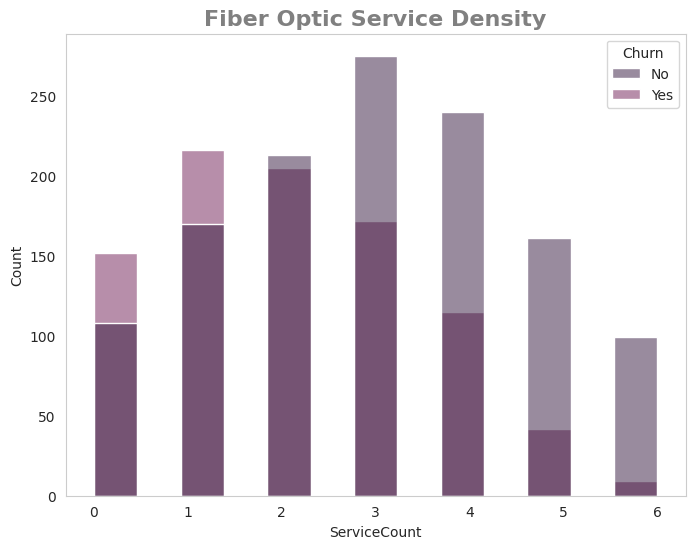

In [210]:
# how many services do these customer have?
# do more services mean greater value?

fiber_optic_customers['ServiceCount'] = (
    fiber_optic_customers[internet_addon]=='Yes'
).sum(axis=1)# tells python to count horizontally

plt.figure(figsize=(8,6))

sns.histplot(
    data=fiber_optic_customers,
    x='ServiceCount',
    hue='Churn'
);

# add title
plt.title(
    "Fiber Optic Service Density",
    fontsize=16,
    fontweight='bold',
    color='grey'
);

plt.grid(False)

# Modelling

